In [1]:
import pandas as pd
import numpy as np
import json
import joblib

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Visualization (later use)
import matplotlib.pyplot as plt

In [2]:

transactions = pd.read_csv("updt_transactions.csv")
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")


with open("train_fraud_labels.json") as f:
    labels = json.load(f)


labels_df = pd.DataFrame(labels["target"].items(), columns=["id", "fraud"])

with open("mcc_codes.json") as f:
    mcc_map = json.load(f)

print("Transactions:", transactions.shape)
print("Users:", users.shape)
print("Cards:", cards.shape)
print("Labels:", labels_df.shape)

Transactions: (800000, 12)
Users: (2000, 14)
Cards: (6146, 13)
Labels: (8914963, 2)


In [4]:
transactions["id"] = transactions["id"].astype(str)
labels_df["id"] = labels_df["id"].astype(str)
df = transactions.merge(labels_df, on="id", how="left")
print("After merging labels:", df.shape)
df.head()

After merging labels: (800000, 13)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,fraud
0,7811809,2010-03-27 06:50:00,1719,4942,$2.64,Swipe Transaction,35451,Miami,FL,33183.0,5812.0,NaN,No
1,7616019,2010-02-05 22:03:00,613,1191,$78.94,Swipe Transaction,1927,Lombard,IL,60148.0,7538.0,NaN,No
2,8258359,2010-07-15 07:18:00,387,4601,$1.38,Swipe Transaction,50783,Amherst,OH,44001.0,5411.0,NaN,No
3,8378505,2010-08-13 07:02:00,1621,5036,$3.82,Swipe Transaction,20519,San Diego,CA,92129.0,5942.0,NaN,No
4,7807728,2010-03-25 22:48:00,947,5534,$35.00,Swipe Transaction,78454,Brooklyn,NY,11232.0,5812.0,NaN,NaN


In [6]:
print(df.shape)
print(df.columns)
df["fraud"].value_counts()

(800000, 13)
Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors', 'fraud'],
      dtype='object')


fraud
No     534049
Yes      1745
Name: count, dtype: int64

In [7]:
df = df.merge(
    users,
    left_on="client_id",
    right_on="id",
    how="left",
    suffixes=("", "_user")
)

print("After merging users:", df.shape)

After merging users: (800000, 27)


In [8]:
df = df.merge(
    cards,
    on="client_id",
    how="left"
)

print("After merging cards:", df.shape)

After merging cards: (3115775, 39)


In [9]:
df["mcc"] = df["mcc"].astype(str)
df["mcc_category"] = df["mcc"].map(mcc_map)

df[["mcc", "mcc_category"]].head()

,mcc,mcc_category
0,5812.0,NaN
1,5812.0,NaN
2,5812.0,NaN
3,7538.0,NaN
4,7538.0,NaN


In [10]:
print(df.shape)
print(df.columns)
df["fraud"].value_counts()

(3115775, 40)
Index(['id_x', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors', 'fraud', 'id_user', 'current_age', 'retirement_age',
       'birth_year', 'birth_month', 'gender', 'address', 'latitude',
       'longitude', 'per_capita_income', 'yearly_income', 'total_debt',
       'credit_score', 'num_credit_cards', 'id_y', 'card_brand', 'card_type',
       'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued',
       'credit_limit', 'acct_open_date', 'year_pin_last_changed',
       'card_on_dark_web', 'mcc_category'],
      dtype='object')


fraud
No     2079395
Yes       6765
Name: count, dtype: int64

In [13]:
df["amount"] = df["amount"].replace(r'[\$,]', '', regex=True).astype(float)

In [14]:
df["fraud"] = df["fraud"].map({"Yes": 1, "No": 0})

In [15]:
df["card_on_dark_web"] = df["card_on_dark_web"].map({"Yes": 1, "No": 0})

In [16]:
# Check missing values
df.isnull().sum()

id_x                           0
date                           0
client_id                      0
card_id                        0
amount                         0
use_chip                       0
merchant_id                    0
merchant_city                  3
merchant_state            337753
zip                       356740
mcc                            0
errors                   3067724
fraud                    1029615
id_user                        0
current_age                    0
retirement_age                 0
birth_year                     0
birth_month                    0
gender                         0
address                        0
latitude                       0
longitude                      0
per_capita_income              0
yearly_income                  0
total_debt                     0
credit_score                   0
num_credit_cards               0
id_y                           0
card_brand                     0
card_type                      0
card_numbe

In [18]:
# Drop rows where target is missing
df = df.dropna(subset=["fraud"])

# Fill numeric columns with 0
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill categorical columns with "Unknown"
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2086160 entries, 0 to 3115774
Data columns (total 40 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id_x                   object 
 1   date                   object 
 2   client_id              int64  
 3   card_id                int64  
 4   amount                 float64
 5   use_chip               object 
 6   merchant_id            int64  
 7   merchant_city          object 
 8   merchant_state         object 
 9   zip                    float64
 10  mcc                    object 
 11  errors                 object 
 12  fraud                  float64
 13  id_user                int64  
 14  current_age            int64  
 15  retirement_age         int64  
 16  birth_year             int64  
 17  birth_month            int64  
 18  gender                 object 
 19  address                object 
 20  latitude               float64
 21  longitude              float64
 22  per_capita_income      

In [20]:
df["fraud"] = df["fraud"].astype(int)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2086160 entries, 0 to 3115774
Data columns (total 40 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id_x                   object 
 1   date                   object 
 2   client_id              int64  
 3   card_id                int64  
 4   amount                 float64
 5   use_chip               object 
 6   merchant_id            int64  
 7   merchant_city          object 
 8   merchant_state         object 
 9   zip                    float64
 10  mcc                    object 
 11  errors                 object 
 12  fraud                  int64  
 13  id_user                int64  
 14  current_age            int64  
 15  retirement_age         int64  
 16  birth_year             int64  
 17  birth_month            int64  
 18  gender                 object 
 19  address                object 
 20  latitude               float64
 21  longitude              float64
 22  per_capita_income      

In [22]:
features = [
    "amount",
    "mcc",
    "current_age",
    "credit_score",
    "num_credit_cards",
    "card_on_dark_web",
    "year_pin_last_changed"
]

X = df[features]
y = df["fraud"]

In [25]:
X = df[features].copy()
y = df["fraud"]

In [26]:
X["mcc"] = pd.to_numeric(X["mcc"], errors="coerce")
X["mcc"] = X["mcc"].fillna(0).astype(int)

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2086160 entries, 0 to 3115774
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   mcc                    int64  
 2   current_age            int64  
 3   credit_score           int64  
 4   num_credit_cards       int64  
 5   card_on_dark_web       int64  
 6   year_pin_last_changed  int64  
dtypes: float64(1), int64(6)
memory usage: 127.3 MB


In [28]:
X = X.fillna(0)

In [29]:
print(X.head())
print(X.shape)
print(y.value_counts())

   amount   mcc  current_age  credit_score  num_credit_cards  \
0    2.64  5812           81           616                 3   
1    2.64  5812           81           616                 3   
2    2.64  5812           81           616                 3   
3   78.94  7538           39           712                 4   
4   78.94  7538           39           712                 4   

   card_on_dark_web  year_pin_last_changed  
0                 0                   2010  
1                 0                   2010  
2                 0                   2008  
3                 0                   2014  
4                 0                   2020  
(2086160, 7)
fraud
0    2079395
1       6765
Name: count, dtype: int64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT (keeps fraud ratio)
)

In [31]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",  # 🔥 KEY LINE
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [32]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [33]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93    415879
           1       0.02      0.91      0.04      1353

    accuracy                           0.87    417232
   macro avg       0.51      0.89      0.49    417232
weighted avg       1.00      0.87      0.93    417232

ROC-AUC: 0.9554036249460792


In [36]:
# Custom threshold
threshold = 0.9

y_pred_custom = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    415879
           1       0.41      0.13      0.20      1353

    accuracy                           1.00    417232
   macro avg       0.71      0.57      0.60    417232
weighted avg       1.00      1.00      1.00    417232



In [37]:
for t in [0.5, 0.7, 0.8, 0.9, 0.95]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    415879
           1       0.02      0.91      0.04      1353

    accuracy                           0.87    417232
   macro avg       0.51      0.89      0.49    417232
weighted avg       1.00      0.87      0.93    417232


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    415879
           1       0.07      0.62      0.12      1353

    accuracy                           0.97    417232
   macro avg       0.53      0.80      0.55    417232
weighted avg       1.00      0.97      0.98    417232


Threshold: 0.8
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    415879
           1       0.12      0.41      0.19      1353

    accuracy                           0.99    417232
   macro avg       0.56      0.70      0.59    417232
weighted avg       1.00   

In [38]:
def predict_fraud(input_data, model, threshold=0.7):
    prob = model.predict_proba(input_data)[:, 1]
    prediction = (prob > threshold).astype(int)
    return prediction, prob

In [39]:
sample = X_test.iloc[[0]]

pred, prob = predict_fraud(sample, model)

print("Prediction:", pred[0])
print("Fraud Probability:", prob[0])

Prediction: 0
Fraud Probability: 0.3234427923647188


In [40]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

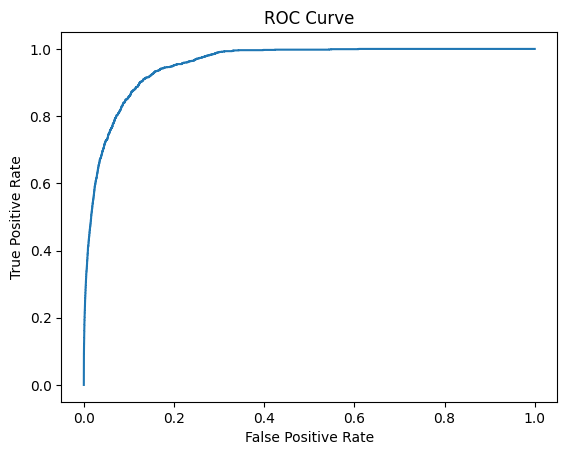

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

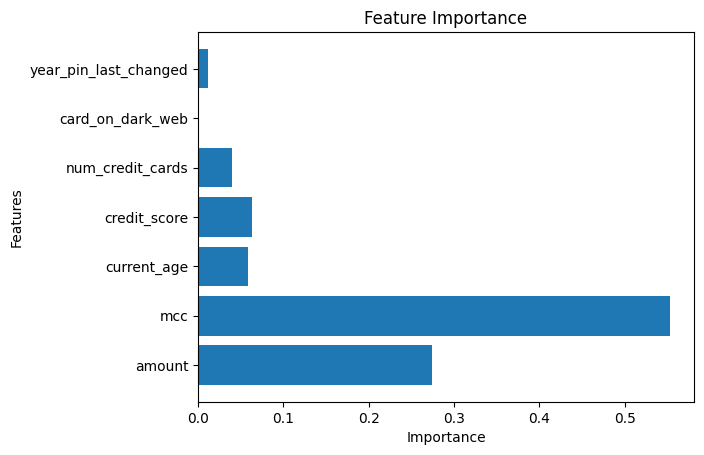

In [43]:
importances = model.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

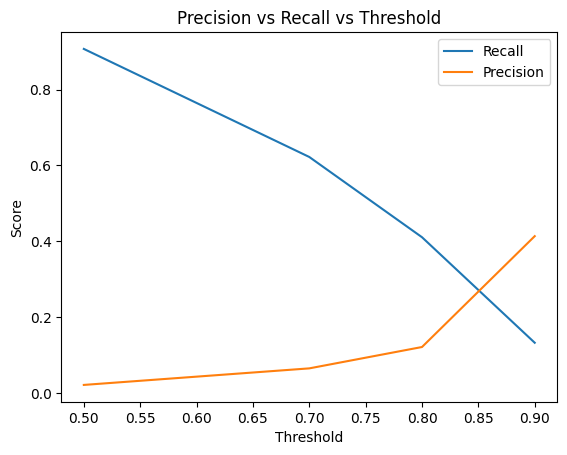

In [45]:
thresholds = [0.5, 0.7, 0.8, 0.9]
recalls = []
precisions = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

plt.figure()
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.legend()
plt.title("Precision vs Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.show()

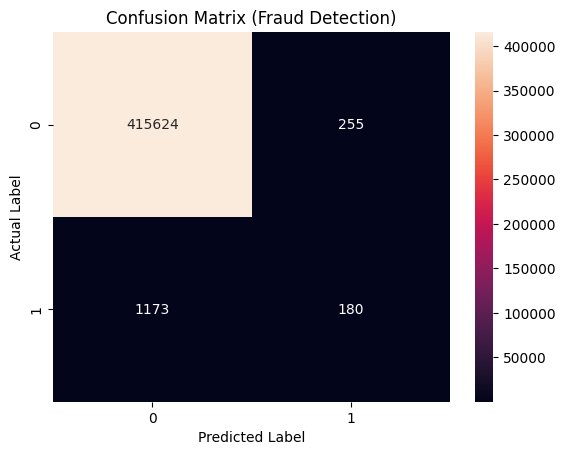

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Fraud Detection)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [47]:
import streamlit as st